In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [3]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.loader import DataLoader as BatchBuilder

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Helper Functions

In [4]:
save_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/ablations")
df_datasets = {}

In [5]:
def collect_wandb_run_dirs(
        sweep_dir,
        type_of_run: Literal['run', 'offline-run']='offline-run'
    ):
    wandb_run_dirs = []
    for d in os.listdir(sweep_dir / "wandb"):
        if type_of_run in d:
            # print(d)
            wandb_run_dirs.append(sweep_dir / "wandb" / d)
    return wandb_run_dirs

In [6]:
def build_sweep_test_results_df(
        wandb_run_dirs,
        split: Literal['1-test-patch', '3-test-patch']='1-test-patch'
    ):
    wandb_run_dir_dfs = []
    for wandb_run_dir in wandb_run_dirs:
        if isinstance(wandb_run_dir, str):
            cfg = f"{wandb_run_dir}/files/user_specified_config.yaml"
            test_res_file = f"{wandb_run_dir}/files/results/test_metrics.csv"
        else:
            cfg = wandb_run_dir/"files"/"user_specified_config.yaml"
            test_res_file = wandb_run_dir/"files"/"results"/"test_metrics.csv"
        with open(cfg, 'r') as f:
            cfg = yaml.safe_load(f)
        test_results_df = pd.read_csv(test_res_file)
        
        test_results_df['dataset'] = cfg['dataset']['dataset_name']
        test_results_df['seed'] = cfg['experiment']['seed']
        test_results_df['backbone_gnn'] = cfg['model']['encoder_params']['gnn_name']
        test_results_df['split'] = split

        wandb_run_dir_dfs.append(test_results_df)
        
    sweep_results = pd.concat(
        objs=wandb_run_dir_dfs,
        ignore_index=True
    )

    return sweep_results

In [7]:
def build_clean_sweep_results_df(
        df: pd.DataFrame,
        metrics: List[str] = [
            "pearson_1hop_nbr",
            "pearson_gene_wise",
            "pearson_gene_wise_1hop_nbr",
            "pearson_cell_wise",
        ]
    ):
    # --- Step 1: groupby and transpose ---
    df_long = df.melt(
        id_vars=["dataset", "seed", "backbone_gnn", "split", "epoch"], 
        var_name="metric", 
        value_name="value"
    )
    
    # --- Step 2: strip mode from metric name ---
    df_long["mode"] = df_long["metric"].str.extract(r"^(train|val|test)")
    df_long["metric"] = df_long["metric"].str.replace(r"^(train|val|test)_", "", regex=True)

    # --- Step 3: pretty names for metric ---
    metric_rename = {
        "pearson_1hop_nbr": "Cell-wise 1-hop",
        "pearson_gene_wise": "Gene-wise",
        "pearson_gene_wise_1hop_nbr": "Gene-wise 1-hop",
        "pearson_cell_wise": "Cell-wise",
    }
    df_long["metric"] = df_long["metric"].map(metric_rename)
    df_long = df_long.dropna()

    # --- Step 4: pretty names for backbone GNN ---
    backbone_rename = {
        "SAGEConv": "GraphSAGE",
        "GATv2Conv": "GAT",
        "GINConv": "GIN",
    }
    df_long["backbone_gnn"] = df_long["backbone_gnn"].map(backbone_rename)
    
    # --- Step 5: pretty names for dataset ---
    dataset_rename = {
        "xhs1000-39b_1p": "Xenium Skin (Human)",
        "mmb0-4b_1p": "Xenium Brain (Mouse)"
    }
    df_long["dataset"] = df_long["dataset"].map(dataset_rename)
    
    # --- Step 6: pretty names for split ---
    split_rename = {
        "1-test-patch": "1 Patch",
        "3-test-patch": "3 Patches",
    }
    df_long["split"] = df_long["split"].map(split_rename)
    
    return df_long

In [99]:
def score_vs_metric_by_gnn(
        df,
        width=4,
        height=3,
        label_order=('GraphSAGE', 'GAT', 'GIN'),
        metric_list=None,
        save_dir=None,
    ):
    s = 11
    plt.rcParams.update({
        "font.size": s,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.weight": 5,
    })

    if metric_list is not None:
        df = df[df["metric"].isin(metric_list)]
    else:
        metric_list = ['Cell-wise 1-hop', 'Cell-wise', 'Gene-wise 1-hop', 'Gene-wise']

    dataset_names = df['dataset'].unique().tolist()
    split_names = df['split'].unique().tolist()
    n_datasets = len(dataset_names)
    n_splits = len(split_names)

    # fixed palette per backbone
    base = sns.color_palette("muted", n_colors=len(label_order))
    palette = {lab: base[i] for i, lab in enumerate(label_order)}

    # one row with (splits * datasets) panels so each split is a contiguous block
    n_cols = n_datasets * n_splits
    fig, axes = plt.subplots(
        1, n_cols,
        figsize=(width * n_cols, height),
        sharey=True,
    )
    if n_cols == 1:
        axes = [axes]
    else:
        axes = list(axes)

    # --- plot: iterate splits first, then datasets (contiguous blocks per split) ---
    idx = 0
    for dataset_name in dataset_names:
        for split_name in split_names:
            ax = axes[idx]
            idx += 1

            data = df[(df['dataset'] == dataset_name) & (df['split'] == split_name)]
            if data.empty:
                ax.axis('off')
                continue

            sns.barplot(
                data=data,
                x="metric",
                y="value",
                hue="backbone_gnn",
                hue_order=list(label_order),
                palette=palette,
                order=metric_list,
                errorbar=None,
                ax=ax,
            )
            ax.tick_params(axis='x', rotation=15, labelright=True)
            ax.set_ylim(0, 1)
            ax.set_ylabel("Pearson Score", fontsize=s)
            ax.set_xlabel("", fontsize=s)
            ax.set_title(split_name)   # split_name as title inside each subplot
            if ax.legend_ is not None:
                ax.legend_.remove()

    # reorder legend entries (shared)
    handles, labels = axes[-1].get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))
    labels = list(label_order)
    handles = [label_to_handle[l] for l in labels if l in label_to_handle]

    # shared legend at bottom
    fig.legend(
        handles, labels,
        title="Backbone GNN",
        fontsize=s,
        title_fontsize=s,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=len(labels),
        frameon=False,
    )

    # leave top space for split headers and bottom space for legend
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.90])

    # --- add dataset headers centered over each dataset block ---
    fig.canvas.draw()  # ensure positions are up-to-date
    for j, dataset_name in enumerate(dataset_names):
        start = j * n_splits
        end = (j + 1) * n_splits - 1
        left = axes[start].get_position().x0
        right = axes[end].get_position().x1
        cx = (left + right) / 2.0
        fig.text(cx, 0.94, dataset_name, ha='center', va='bottom',
                 fontsize=s, fontweight='bold')

    if save_dir is not None:
        fname = save_dir / "backbone_gnn.pdf"
        plt.savefig(fname, bbox_inches="tight")
    else:
        plt.show()

# Dataset: xhs1000-39b_1p-oriented-7

In [9]:
df_datasets_splits = []

## 1-region Test

In [66]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/backbone_gnn/20250915-081906")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='1-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(sweep_results)
display(df_long.head(3))

df_datasets_splits.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,epoch,dataset,seed,backbone_gnn,split
0,0.0062,0.500605,0.782040,0.043500,0.148555,19,xhs1000-39b_1p,1,SAGEConv,1-test-patch
1,0.0050,0.479581,0.737958,0.044248,0.128782,17,xhs1000-39b_1p,0,SAGEConv,1-test-patch
2,0.0062,0.500605,0.782040,0.043500,0.148555,19,xhs1000-39b_1p,1,SAGEConv,1-test-patch


,dataset,seed,backbone_gnn,split,epoch,metric,value,mode
8,Xenium Skin (Human),1,GraphSAGE,1 Patch,19,Cell-wise,0.500605,test
9,Xenium Skin (Human),0,GraphSAGE,1 Patch,17,Cell-wise,0.479581,test
10,Xenium Skin (Human),1,GraphSAGE,1 Patch,19,Cell-wise,0.500605,test


## 3-region Test

In [11]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/backbone_gnn/20250914-223915")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='3-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(sweep_results)
display(df_long.head(3))

df_datasets_splits.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,epoch,dataset,seed,backbone_gnn,split
0,0.0250,0.410830,0.738857,0.105257,0.295920,19,xhs1000-39b_1p,0,SAGEConv,3-test-patch
1,0.0254,0.437737,0.777079,0.113786,0.308713,19,xhs1000-39b_1p,0,GINConv,3-test-patch
2,0.0218,0.348589,0.649412,0.073060,0.214774,19,xhs1000-39b_1p,0,GATv2Conv,3-test-patch


,dataset,seed,backbone_gnn,split,epoch,metric,value,mode
7,Xenium Skin (Human),0,GraphSAGE,3 Patches,19,Cell-wise,0.410830,test
8,Xenium Skin (Human),0,GIN,3 Patches,19,Cell-wise,0.437737,test
9,Xenium Skin (Human),0,GAT,3 Patches,19,Cell-wise,0.348589,test


# Dataset: mmb04-4b_1p

## 1-region Test

In [35]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/backbone_gnn/20250915-082008")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='1-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(sweep_results)
display(df_long.head(3))

df_datasets_splits.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,epoch,dataset,seed,backbone_gnn,split
0,0.0046,0.396519,0.571497,-0.000997,0.017455,12,mmb0-4b_1p,1,GATv2Conv,1-test-patch
1,0.0106,0.610370,0.844103,0.012596,0.066898,18,mmb0-4b_1p,1,GINConv,1-test-patch
2,0.0072,0.660117,0.884623,0.004423,0.100174,18,mmb0-4b_1p,0,SAGEConv,1-test-patch


,dataset,seed,backbone_gnn,split,epoch,metric,value,mode
9,Xenium Brain (Mouse),1,GAT,1 Patch,12,Cell-wise,0.396519,test
10,Xenium Brain (Mouse),1,GIN,1 Patch,18,Cell-wise,0.610370,test
11,Xenium Brain (Mouse),0,GraphSAGE,1 Patch,18,Cell-wise,0.660117,test


## 3-region Test

In [13]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/backbone_gnn/20250914-232614")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='3-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(sweep_results)
display(df_long.head(3))

df_datasets_splits.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,epoch,dataset,seed,backbone_gnn,split
0,0.0330,0.645431,0.878585,0.124403,0.334578,19,mmb0-4b_1p,0,GINConv,3-test-patch
1,0.0172,0.423633,0.607143,0.054069,0.187797,19,mmb0-4b_1p,0,GATv2Conv,3-test-patch
2,0.0264,0.636755,0.893444,0.110635,0.361938,19,mmb0-4b_1p,0,SAGEConv,3-test-patch


,dataset,seed,backbone_gnn,split,epoch,metric,value,mode
9,Xenium Brain (Mouse),0,GIN,3 Patches,19,Cell-wise,0.645431,test
10,Xenium Brain (Mouse),0,GAT,3 Patches,19,Cell-wise,0.423633,test
11,Xenium Brain (Mouse),0,GraphSAGE,3 Patches,19,Cell-wise,0.636755,test


# Final Plot

In [67]:
df_long = pd.concat(
            objs=df_datasets_splits,
            ignore_index=True
        )

df_avg = df_long.groupby(
        ['dataset', 'split', 'backbone_gnn', 'metric']
        )['value'].mean()
display(df_avg)

dataset               split      backbone_gnn  metric         
Xenium Brain (Mouse)  1 Patch    GAT           Cell-wise          0.439715
                                               Cell-wise 1-hop    0.641702
                                               Gene-wise          0.009546
                                               Gene-wise 1-hop    0.035217
                                 GIN           Cell-wise          0.639048
                                               Cell-wise 1-hop    0.867333
                                               Gene-wise          0.006585
                                               Gene-wise 1-hop    0.066642
                                 GraphSAGE     Cell-wise          0.661163
                                               Cell-wise 1-hop    0.890220
                                               Gene-wise          0.012238
                                               Gene-wise 1-hop    0.111499
                      3 Patches  GAT 

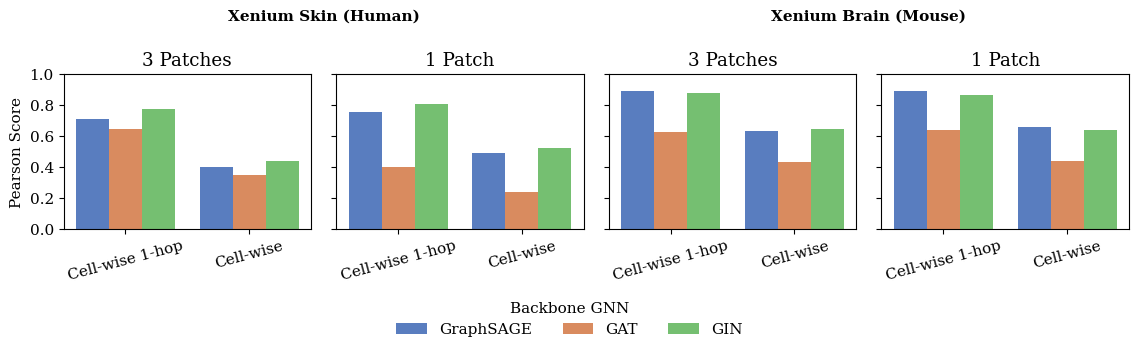

In [104]:
score_vs_metric_by_gnn(
    df_long,
    save_dir=save_dir,
    width=3,
    height=3,
    # metric_list= ['Cell-wise 1-hop', 'Gene-wise 1-hop'],
    metric_list= ['Cell-wise 1-hop', 'Cell-wise'],
)

In [39]:
display(df_long)

,dataset,seed,backbone_gnn,split,epoch,metric,value,mode
0,Xenium Skin (Human),0,GraphSAGE,3 Patches,19,Cell-wise,0.410830,test
1,Xenium Skin (Human),0,GIN,3 Patches,19,Cell-wise,0.437737,test
2,Xenium Skin (Human),0,GAT,3 Patches,19,Cell-wise,0.348589,test
3,Xenium Skin (Human),0,GIN,3 Patches,19,Cell-wise,0.437737,test
4,Xenium Skin (Human),0,GAT,3 Patches,19,Cell-wise,0.348589,test
5,Xenium Skin (Human),0,GraphSAGE,3 Patches,19,Cell-wise,0.410830,test
6,Xenium Skin (Human),1,GraphSAGE,3 Patches,19,Cell-wise,0.379068,test
7,Xenium Skin (Human),0,GraphSAGE,3 Patches,19,Cell-wise 1-hop,0.738857,test
8,Xenium Skin (Human),0,GIN,3 Patches,19,Cell-wise 1-hop,0.777079,test
9,Xenium Skin (Human),0,GAT,3 Patches,19,Cell-wise 1-hop,0.649412,test
